# Time-Series Forecasting With a Custom GRU

This notebook builds a full forecasting pipeline from scratch.

We use the same forecasting setup on two real-world datasets:

1. Daily minimum temperatures in Melbourne.
2. Electric production

Models covered in this notebook:

- MLPBaseline: a lag-feature baseline with no recurrent memory,
- CustomGRU: implemented manually from gate equations,
- LSTMRegressor: prebuilt comparison model,
- TransformerRegressor: prebuilt comparison model.

We also run an ablation study for the custom GRU with:

- half the original window size,
- the original window size,
- double the original window size.

In [1]:
import copy
import math
import random
import warnings
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

# Mandatory assignment parameters. These names stay visible throughout the notebook.
window_size = 10
prediction_horizon = 2
hidden_size = 14

batch_size = 64
learning_rate = 1e-3
max_epochs = 30
patience = 5
train_ratio = 0.70
val_ratio = 0.15
seed = 7

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Asus\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Asus\AppData\Roaming\Python\Python311\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\Asus\AppData\Roaming\Python\Python311\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.

In [2]:
ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)

DATA_SOURCES = {
    "temperature": {
        "path": DATA_DIR / "daily_min_temperatures.csv",
        "url": "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv",
    },
    "electricity": {
        "path": DATA_DIR / "Electric_Production.csv",
    },
}


def set_seed(value: int = seed) -> None:
    random.seed(value)
    np.random.seed(value)
    torch.manual_seed(value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(value)


def ensure_data_files() -> None:
    temperature_item = DATA_SOURCES["temperature"]
    if not temperature_item["path"].exists():
        print(f"Downloading {temperature_item['path'].name} ...")
        urlretrieve(temperature_item["url"], temperature_item["path"])

    electricity_item = DATA_SOURCES["electricity"]
    if not electricity_item["path"].exists():
        raise FileNotFoundError(
            f"Expected {electricity_item['path'].name} inside {DATA_DIR}. "
            "Place the corrected Kaggle CSV there before running the notebook."
        )


class StandardScaler1D:
    """Simple scaler so the transformation logic stays visible."""

    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, values):
        values = np.asarray(values, dtype=np.float32)
        self.mean_ = float(values.mean())
        self.std_ = float(values.std())
        if self.std_ == 0.0:
            self.std_ = 1.0
        return self

    def transform(self, values):
        values = np.asarray(values, dtype=np.float32)
        return (values - self.mean_) / self.std_

    def inverse_transform(self, values):
        values = np.asarray(values, dtype=np.float32)
        return values * self.std_ + self.mean_


class StandardScalerND:
    """Column-wise scaler for time-series features."""

    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, values):
        values = np.asarray(values, dtype=np.float32)
        self.mean_ = values.mean(axis=0, keepdims=True)
        self.std_ = values.std(axis=0, keepdims=True)
        self.std_[self.std_ == 0.0] = 1.0
        return self

    def transform(self, values):
        values = np.asarray(values, dtype=np.float32)
        return (values - self.mean_) / self.std_


def load_temperature_dataset(csv_path: Path) -> dict:
    df = pd.read_csv(csv_path)
    df["Date"] = pd.to_datetime(df["Date"])
    frame = df.rename(columns={"Date": "timestamp", "Temp": "temperature"}).copy()
    frame["dataset"] = "Daily Minimum Temperatures"
    return {
        "name": "Daily Minimum Temperatures",
        "frame": frame[["timestamp", "temperature", "dataset"]],
        "feature_columns": ["temperature"],
        "target_column": "temperature",
    }


def load_electricity_dataset(csv_path: Path) -> dict:
    df = pd.read_csv(csv_path)
    df["DATE"] = pd.to_datetime(df["DATE"], dayfirst=True)
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

    frame = df.rename(columns={"DATE": "timestamp", "Value": "electricity_production"}).copy()
    frame = frame.sort_values("timestamp").reset_index(drop=True)
    frame["electricity_production"] = frame["electricity_production"].interpolate().bfill().ffill()
    frame["dataset"] = "Electric Production"

    return {
        "name": "Electric Production",
        "frame": frame[["timestamp", "electricity_production", "dataset"]],
        "feature_columns": ["electricity_production"],
        "target_column": "electricity_production",
    }


ensure_data_files()

raw_series_catalog = {
    "Daily Minimum Temperatures": load_temperature_dataset(DATA_SOURCES["temperature"]["path"]),
    "Electric Production": load_electricity_dataset(DATA_SOURCES["electricity"]["path"]),
}

for name, dataset_info in raw_series_catalog.items():
    frame = dataset_info["frame"]
    print(
        f"{name}: {len(frame)} rows, range = {frame['timestamp'].min().date()} to {frame['timestamp'].max().date()}, "
        f"features = {dataset_info['feature_columns']}"
    )

Daily Minimum Temperatures: 3650 rows, range = 1981-01-01 to 1990-12-31, features = ['temperature']
Electric Production: 397 rows, range = 1985-01-01 to 2018-01-01, features = ['electricity_production']


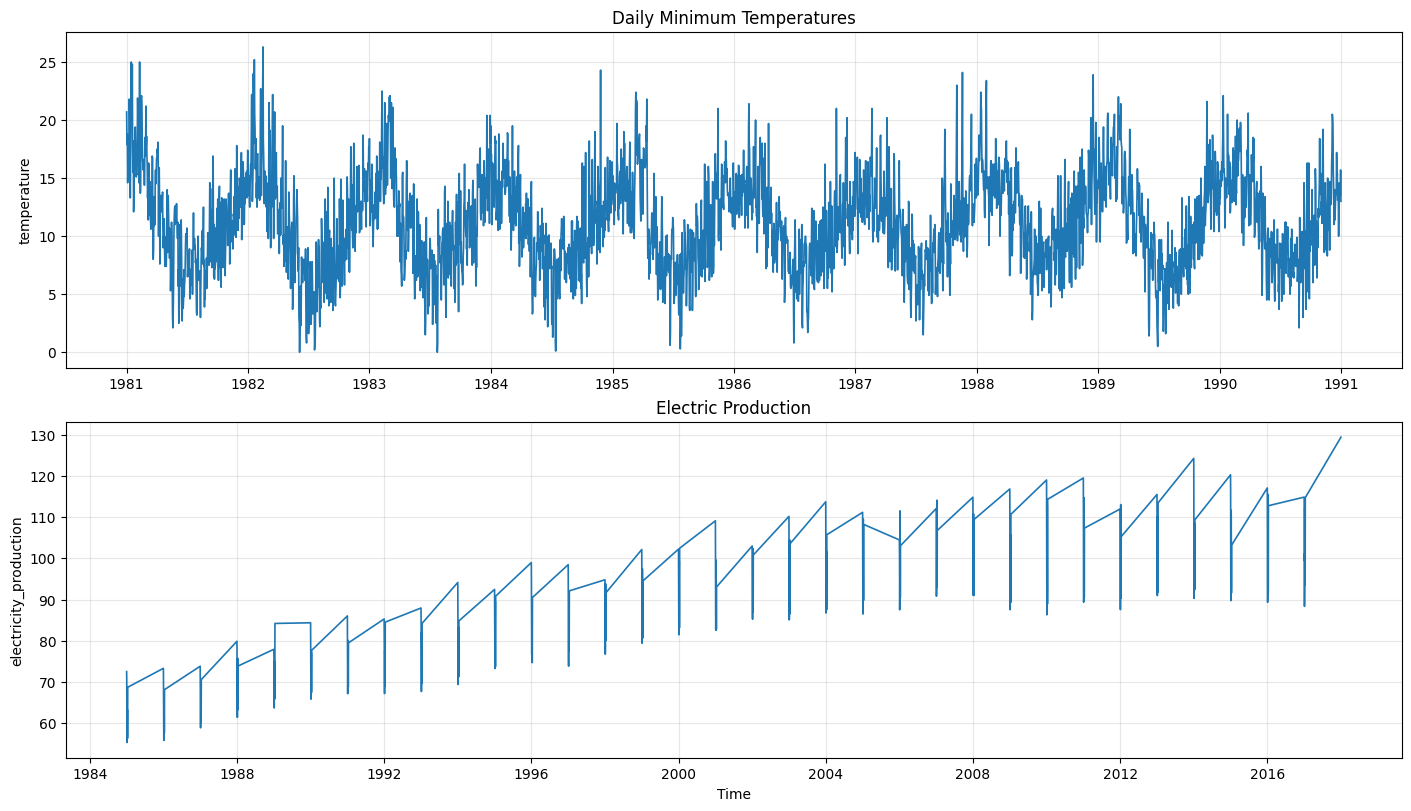

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), constrained_layout=True)

for ax, (name, dataset_info) in zip(axes, raw_series_catalog.items()):
    frame = dataset_info["frame"]
    target_column = dataset_info["target_column"]
    ax.plot(frame["timestamp"], frame[target_column], linewidth=1.2)
    ax.set_title(name)
    ax.set_ylabel(target_column)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time")
plt.show()


A forecasting model does not see the future. We preserve that rule in two ways:

1. Chronological split only: the earliest chunk is training data, the middle chunk is validation data, and the latest chunk is test data.
2. Windowed supervision: each input window contains only past values, and each target contains the next prediction_horizon values.

For the electricity dataset, the input window contains only past electricity production values and the target contains the next two future production values.

An important detail is that validation and test windows are allowed to *look back* into earlier periods. That is realistic. When forecasting on day t, we are allowed to use observed history from days < t; we are simply not allowed to train on the future targets.

In [4]:
def build_windowed_problem(dataset_info: dict, current_window_size: int, horizon: int):
    frame = dataset_info["frame"].sort_values("timestamp").reset_index(drop=True).copy()
    feature_columns = dataset_info["feature_columns"]
    target_column = dataset_info["target_column"]

    feature_values = frame[feature_columns].to_numpy(dtype=np.float32)
    target_values = frame[target_column].to_numpy(dtype=np.float32)
    timestamps = frame["timestamp"].to_numpy()

    train_end = int(len(target_values) * train_ratio)
    val_end = int(len(target_values) * (train_ratio + val_ratio))

    feature_scaler = StandardScalerND().fit(feature_values[:train_end])
    target_scaler = StandardScaler1D().fit(target_values[:train_end])

    scaled_features = feature_scaler.transform(feature_values)
    scaled_target = target_scaler.transform(target_values)

    x_scaled, y_scaled = [], []
    x_target_raw, y_target_raw = [], []
    x_feature_raw = []
    x_times, y_times = [], []
    splits = []

    # Each sample is a direct multi-step forecasting pair:
    # input  = historical features over [t : t + window_size]
    # target = future target values over [t + window_size : t + window_size + horizon]
    for start in range(len(target_values) - current_window_size - horizon + 1):
        input_end = start + current_window_size
        target_end = input_end + horizon

        target_start_idx = input_end
        target_end_idx = target_end

        if target_end_idx <= train_end:
            split_name = "train"
        elif target_start_idx >= train_end and target_end_idx <= val_end:
            split_name = "val"
        elif target_start_idx >= val_end:
            split_name = "test"
        else:
            # Skip boundary cases where the target straddles two splits.
            continue

        x_scaled.append(scaled_features[start:input_end])
        y_scaled.append(scaled_target[input_end:target_end])
        x_target_raw.append(target_values[start:input_end])
        y_target_raw.append(target_values[input_end:target_end])
        x_feature_raw.append(feature_values[start:input_end])
        x_times.append(timestamps[start:input_end])
        y_times.append(timestamps[input_end:target_end])
        splits.append(split_name)

    split_array = np.asarray(splits)
    x_scaled = np.asarray(x_scaled, dtype=np.float32).reshape(-1, current_window_size, len(feature_columns))
    y_scaled = np.asarray(y_scaled, dtype=np.float32).reshape(-1, horizon)
    x_target_raw = np.asarray(x_target_raw, dtype=np.float32).reshape(-1, current_window_size)
    y_target_raw = np.asarray(y_target_raw, dtype=np.float32).reshape(-1, horizon)
    x_feature_raw = np.asarray(x_feature_raw, dtype=np.float32).reshape(-1, current_window_size, len(feature_columns))
    x_times = np.asarray(x_times, dtype="datetime64[ns]").reshape(-1, current_window_size)
    y_times = np.asarray(y_times, dtype="datetime64[ns]").reshape(-1, horizon)

    sample_table = {
        split_name: {
            "x_scaled": x_scaled[split_array == split_name],
            "y_scaled": y_scaled[split_array == split_name],
            "x_target_raw": x_target_raw[split_array == split_name],
            "y_target_raw": y_target_raw[split_array == split_name],
            "x_feature_raw": x_feature_raw[split_array == split_name],
            "x_times": x_times[split_array == split_name],
            "y_times": y_times[split_array == split_name],
        }
        for split_name in ["train", "val", "test"]
    }

    loaders = {}
    for split_name, split_data in sample_table.items():
        x_tensor = torch.as_tensor(split_data["x_scaled"], dtype=torch.float32)
        y_tensor = torch.as_tensor(split_data["y_scaled"], dtype=torch.float32)
        dataset = TensorDataset(x_tensor, y_tensor)
        loaders[split_name] = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=(split_name == "train"),
        )

    return {
        "name": frame["dataset"].iloc[0],
        "frame": frame,
        "feature_values": feature_values,
        "target_values": target_values,
        "timestamps": timestamps,
        "train_end": train_end,
        "val_end": val_end,
        "window_size": current_window_size,
        "horizon": horizon,
        "feature_columns": feature_columns,
        "target_column": target_column,
        "num_features": len(feature_columns),
        "feature_scaler": feature_scaler,
        "target_scaler": target_scaler,
        "samples": sample_table,
        "loaders": loaders,
    }


problems = {
    name: build_windowed_problem(dataset_info, window_size, prediction_horizon)
    for name, dataset_info in raw_series_catalog.items()
}

for name, problem in problems.items():
    print(
        f"{name}: train={len(problem['samples']['train']['x_scaled'])}, "
        f"val={len(problem['samples']['val']['x_scaled'])}, "
        f"test={len(problem['samples']['test']['x_scaled'])}"
    )

Daily Minimum Temperatures: train=2544, val=546, test=547
Electric Production: train=266, val=59, test=59


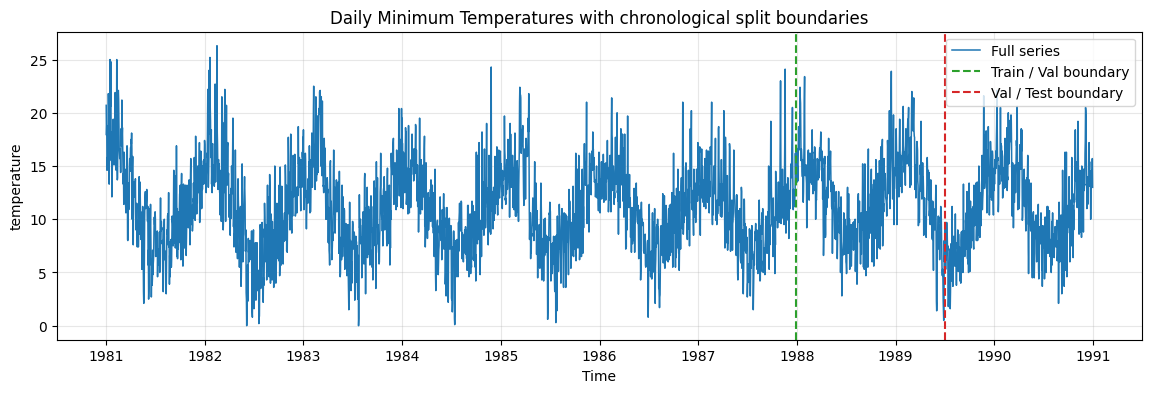

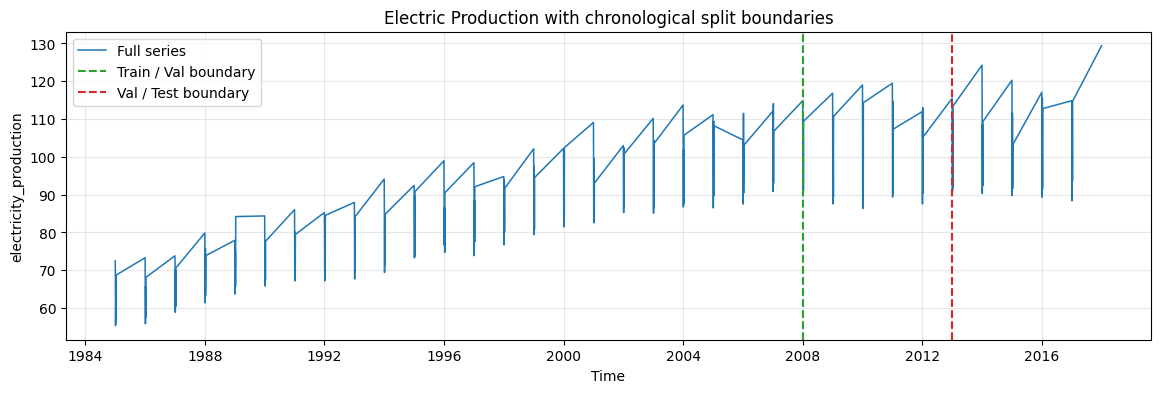

In [5]:
def plot_split_boundaries(problem):
    frame = problem["frame"]
    train_cut = frame.loc[problem["train_end"] - 1, "timestamp"]
    val_cut = frame.loc[problem["val_end"] - 1, "timestamp"]

    plt.figure(figsize=(14, 4))
    plt.plot(frame["timestamp"], frame[problem["target_column"]], label="Full series", linewidth=1.1)
    plt.axvline(train_cut, color="tab:green", linestyle="--", label="Train / Val boundary")
    plt.axvline(val_cut, color="tab:red", linestyle="--", label="Val / Test boundary")
    plt.title(f"{problem['name']} with chronological split boundaries")
    plt.xlabel("Time")
    plt.ylabel(problem["target_column"])
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


for problem in problems.values():
    plot_split_boundaries(problem)

In [6]:
# Inspecting one raw window makes the supervised learning conversion explicit.
example_problem = problems["Electric Production"]
example_idx = 0

example_input_table = pd.DataFrame(
    example_problem["samples"]["train"]["x_feature_raw"][example_idx],
    columns=example_problem["feature_columns"],
)
example_input_table.insert(0, "timestamp", example_problem["samples"]["train"]["x_times"][example_idx])
example_input_table["role"] = "input"

example_target_table = pd.DataFrame(
    {
        "timestamp": example_problem["samples"]["train"]["y_times"][example_idx],
        example_problem["target_column"]: example_problem["samples"]["train"]["y_target_raw"][example_idx],
        "role": "target",
    }
)

print("Input window given to the model for the electricity production dataset:")
display(example_input_table)
print("Future values the model must predict:")
display(example_target_table)

Input window given to the model for the electricity production dataset:


,timestamp,electricity_production,role
0,1985-01-01,72.505203,input
1,1985-01-02,70.671997,input
2,1985-01-03,62.450199,input
3,1985-01-04,57.471401,input
4,1985-01-05,55.315102,input
5,1985-01-06,58.090401,input
6,1985-01-07,62.620201,input
7,1985-01-08,63.248501,input
8,1985-01-09,60.584599,input
9,1985-01-10,56.315399,input


Future values the model must predict:


,timestamp,electricity_production,role
0,1985-01-11,58.0005,target
1,1985-01-12,68.7145,target


In [7]:
first_train_batch = next(iter(example_problem["loaders"]["train"]))
x_batch, y_batch = first_train_batch

print("Model input shape:", tuple(x_batch.shape))
print("Model target shape:", tuple(y_batch.shape))
print()
print("The recurrent models see tensors shaped as:")
print("  [batch, window_size, features] =", tuple(x_batch.shape))
print()
print("Feature order:", example_problem["feature_columns"])
print()
print("The first scaled training window is:")
display(pd.DataFrame(x_batch[0].tolist(), columns=example_problem["feature_columns"]))
print()
print("The 2-step target the model must predict is:")
print(y_batch[0].tolist())

Model input shape: (64, 10, 1)
Model target shape: (64, 2)

The recurrent models see tensors shaped as:
  [batch, window_size, features] = (64, 10, 1)

Feature order: ['electricity_production']

The first scaled training window is:


,electricity_production
0,0.703513
1,-0.015650
2,-0.042383
3,0.527025
4,0.938974
5,1.191388
6,0.373628
7,-0.032263
8,-0.014424
9,0.718733



The 2-step target the model must predict is:
[1.4410960674285889, 0.8761129975318909]



The baseline MLP receives the same lag window, but it treats that window as a fixed feature vector. It has no recurrent hidden state.

The custom GRU below is implemented manually from the gate equations:

- update gate z_t decides how much past state to keep,
- reset gate r_t decides how strongly to reuse past state when creating the candidate,
- candidate state n_t mixes the new input with the gated history,
- final hidden state h_t blends the old and new information.

In other words, the GRU is sequence-aware because it updates a hidden summary one time step at a time.

In [8]:
class MLPBaseline(nn.Module):
    def __init__(self, current_window_size: int, input_size: int, forecast_horizon: int, hidden_units: int):
        super().__init__()
        flattened_size = current_window_size * input_size
        self.network = nn.Sequential(
            nn.Linear(flattened_size, hidden_units),
            nn.ReLU(),
            nn.Linear(hidden_units, hidden_units),
            nn.ReLU(),
            nn.Linear(hidden_units, forecast_horizon),
        )

    def forward(self, x):
        # The MLP loses explicit temporal recurrence because we flatten the full window.
        x = x.reshape(x.size(0), -1)
        return self.network(x)


class CustomGRU(nn.Module):
    def __init__(self, input_size: int, hidden_units: int, forecast_horizon: int):
        super().__init__()
        self.hidden_units = hidden_units

        # We define the gate parameters ourselves instead of calling nn.GRU.
        self.W_xz = nn.Parameter(torch.randn(input_size, hidden_units) * 0.1)
        self.W_hz = nn.Parameter(torch.randn(hidden_units, hidden_units) * 0.1)
        self.b_z = nn.Parameter(torch.zeros(hidden_units))

        self.W_xr = nn.Parameter(torch.randn(input_size, hidden_units) * 0.1)
        self.W_hr = nn.Parameter(torch.randn(hidden_units, hidden_units) * 0.1)
        self.b_r = nn.Parameter(torch.zeros(hidden_units))

        self.W_xn = nn.Parameter(torch.randn(input_size, hidden_units) * 0.1)
        self.W_hn = nn.Parameter(torch.randn(hidden_units, hidden_units) * 0.1)
        self.b_n = nn.Parameter(torch.zeros(hidden_units))

        self.output = nn.Linear(hidden_units, forecast_horizon)

    def forward(self, x):
        batch_size_local = x.size(0)
        hidden = torch.zeros(batch_size_local, self.hidden_units, device=x.device)

        for step in range(x.size(1)):
            x_t = x[:, step, :]

            # Update gate: keep old memory when z is high.
            z_t = torch.sigmoid(x_t @ self.W_xz + hidden @ self.W_hz + self.b_z)

            # Reset gate: reduce the influence of old memory when building the candidate.
            r_t = torch.sigmoid(x_t @ self.W_xr + hidden @ self.W_hr + self.b_r)

            candidate = torch.tanh(x_t @ self.W_xn + (r_t * hidden) @ self.W_hn + self.b_n)

            # Blend previous state and candidate state.
            hidden = (1.0 - z_t) * candidate + z_t * hidden

        return self.output(hidden)


class LSTMRegressor(nn.Module):
    def __init__(self, input_size: int, hidden_units: int, forecast_horizon: int):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_units, batch_first=True)
        self.output = nn.Linear(hidden_units, forecast_horizon)

    def forward(self, x):
        _, (hidden_state, _) = self.lstm(x)
        return self.output(hidden_state[-1])


class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 4096):
        super().__init__()
        positions = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )
        pe = torch.zeros(max_len, d_model, dtype=torch.float32)
        pe[:, 0::2] = torch.sin(positions * div_term)
        pe[:, 1::2] = torch.cos(positions * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, : x.size(1), :]


class TransformerRegressor(nn.Module):
    def __init__(self, input_size: int, hidden_units: int, forecast_horizon: int):
        super().__init__()
        self.input_projection = nn.Linear(input_size, hidden_units)
        self.position = PositionalEncoding(hidden_units)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_units,
            nhead=2,
            dim_feedforward=hidden_units * 4,
            dropout=0.1,
            activation="gelu",
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.output = nn.Linear(hidden_units, forecast_horizon)

    def forward(self, x):
        encoded = self.input_projection(x)
        encoded = self.position(encoded)
        encoded = self.encoder(encoded)
        # We read the final token representation because it summarizes the full input window.
        return self.output(encoded[:, -1, :])


model_factories = {
    "MLP baseline": lambda problem: MLPBaseline(problem["window_size"], problem["num_features"], prediction_horizon, hidden_size),
    "Custom GRU": lambda problem: CustomGRU(problem["num_features"], hidden_size, prediction_horizon),
    "LSTM": lambda problem: LSTMRegressor(problem["num_features"], hidden_size, prediction_horizon),
    "Transformer": lambda problem: TransformerRegressor(problem["num_features"], hidden_size, prediction_horizon),
}

Training Utilities:

We optimize MSE because it strongly penalizes large misses. That is helpful in forecasting because large misses are exactly the failures we care about inspecting.

Early stopping uses validation loss only. This keeps the test set untouched until the very end.

In [9]:
def evaluate_loss(model, data_loader, criterion):
    model.eval()
    losses = []
    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            preds = model(xb)
            losses.append(float(criterion(preds, yb).item()))
    return float(np.mean(losses))


def train_model(model, problem):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    best_state = None
    best_val = float("inf")
    wait = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(max_epochs):
        model.train()
        batch_losses = []

        for xb, yb in problem["loaders"]["train"]:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            batch_losses.append(float(loss.item()))

        train_loss = float(np.mean(batch_losses))
        val_loss = evaluate_loss(model, problem["loaders"]["val"], criterion)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history


def predict_scaled(model, data_loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            preds.append(np.asarray(model(xb).cpu().tolist(), dtype=np.float32))
            trues.append(np.asarray(yb.tolist(), dtype=np.float32))
    return np.concatenate(preds, axis=0), np.concatenate(trues, axis=0)


def compute_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true.reshape(-1), y_pred.reshape(-1))
    mae = mean_absolute_error(y_true.reshape(-1), y_pred.reshape(-1))
    rmse = math.sqrt(mse)
    return {"MSE": mse, "MAE": mae, "RMSE": rmse}


def build_prediction_frame(target_times, y_true, y_pred):
    rows = []
    for sample_idx in range(len(y_true)):
        for step_idx in range(y_true.shape[1]):
            rows.append(
                {
                    "sample_idx": sample_idx,
                    "step_ahead": step_idx + 1,
                    "timestamp": pd.Timestamp(target_times[sample_idx, step_idx]),
                    "actual": float(y_true[sample_idx, step_idx]),
                    "predicted": float(y_pred[sample_idx, step_idx]),
                    "abs_error": float(abs(y_true[sample_idx, step_idx] - y_pred[sample_idx, step_idx])),
                }
            )
    return pd.DataFrame(rows)


def run_single_experiment(problem, model_name, model_builder):
    set_seed(seed)
    model = model_builder(problem).to(device)
    history = train_model(model, problem)

    pred_scaled, true_scaled = predict_scaled(model, problem["loaders"]["test"])
    target_scaler = problem["target_scaler"]
    pred_raw = target_scaler.inverse_transform(pred_scaled)
    true_raw = target_scaler.inverse_transform(true_scaled)

    metrics = compute_metrics(true_raw, pred_raw)
    prediction_frame = build_prediction_frame(problem["samples"]["test"]["y_times"], true_raw, pred_raw)

    sample_errors = np.abs(true_raw - pred_raw).max(axis=1)
    worst_sample_idx = int(np.argmax(sample_errors))

    return {
        "model_name": model_name,
        "history": history,
        "metrics": metrics,
        "pred_scaled": pred_scaled,
        "true_scaled": true_scaled,
        "pred_raw": pred_raw,
        "true_raw": true_raw,
        "prediction_frame": prediction_frame,
        "worst_sample_idx": worst_sample_idx,
    }

All four models below use the same main assignment settings:

- window_size = 10
- prediction_horizon = 2
- hidden_size = 14

In [10]:
default_runs = {}
metrics_rows = []

for dataset_name, problem in problems.items():
    default_runs[dataset_name] = {}
    print(f"Running default models on: {dataset_name}")
    for model_name, model_builder in model_factories.items():
        run = run_single_experiment(problem, model_name, model_builder)
        default_runs[dataset_name][model_name] = run
        metrics_rows.append(
            {
                "dataset": dataset_name,
                "model": model_name,
                **run["metrics"],
                "epochs_trained": len(run["history"]["train_loss"]),
            }
        )
        print(
            f"  {model_name:<12} | "
            f"MSE={run['metrics']['MSE']:.4f} | "
            f"MAE={run['metrics']['MAE']:.4f} | "
            f"RMSE={run['metrics']['RMSE']:.4f}"
        )
    print()

metrics_df = pd.DataFrame(metrics_rows).sort_values(["dataset", "RMSE", "MAE"]).reset_index(drop=True)
metrics_df.round(4)

Running default models on: Daily Minimum Temperatures
  MLP baseline | MSE=5.7539 | MAE=1.8605 | RMSE=2.3987
  Custom GRU   | MSE=5.7237 | MAE=1.8574 | RMSE=2.3924
  LSTM         | MSE=5.7939 | MAE=1.8634 | RMSE=2.4071
  Transformer  | MSE=5.6609 | MAE=1.8450 | RMSE=2.3793

Running default models on: Electric Production
  MLP baseline | MSE=55.2237 | MAE=5.8390 | RMSE=7.4313
  Custom GRU   | MSE=116.8646 | MAE=8.8691 | RMSE=10.8104
  LSTM         | MSE=132.4550 | MAE=9.3899 | RMSE=11.5089
  Transformer  | MSE=54.2317 | MAE=5.8339 | RMSE=7.3642



,dataset,model,MSE,MAE,RMSE,epochs_trained
0,Daily Minimum Temperatures,Transformer,5.6609,1.8450,2.3793,30
1,Daily Minimum Temperatures,Custom GRU,5.7237,1.8574,2.3924,30
2,Daily Minimum Temperatures,MLP baseline,5.7539,1.8605,2.3987,27
3,Daily Minimum Temperatures,LSTM,5.7939,1.8634,2.4071,30
4,Electric Production,Transformer,54.2317,5.8339,7.3642,30
5,Electric Production,MLP baseline,55.2237,5.8390,7.4313,30
6,Electric Production,Custom GRU,116.8646,8.8691,10.8104,30
7,Electric Production,LSTM,132.4550,9.3899,11.5089,30


In [21]:
from IPython.display import Markdown


def build_results_summary(metrics_table: pd.DataFrame) -> str:
    lines = []
    for dataset_name in metrics_table["dataset"].unique():
        subset = metrics_table[metrics_table["dataset"] == dataset_name].sort_values(["RMSE", "MAE"])
        best = subset.iloc[0]
        worst = subset.iloc[-1]
        lines.append(
            f"- **{dataset_name}:** best test RMSE came from **{best['model']}** "
            f"({best['RMSE']:.4f}), while the weakest result here was **{worst['model']}** "
            f"({worst['RMSE']:.4f})."
        )
    lines.append("")
    lines.append(
        "- These lines are generated from the actual notebook metrics so the text stays aligned with the executed results."
    )
    return "\n".join(lines)


display(Markdown(build_results_summary(metrics_df)))

- **Daily Minimum Temperatures:** best test RMSE came from **Transformer** (2.3793), while the weakest result here was **LSTM** (2.4071).
- **Electric Production:** best test RMSE came from **Transformer** (7.3642), while the weakest result here was **LSTM** (11.5089).

- These lines are generated from the actual notebook metrics so the text stays aligned with the executed results.

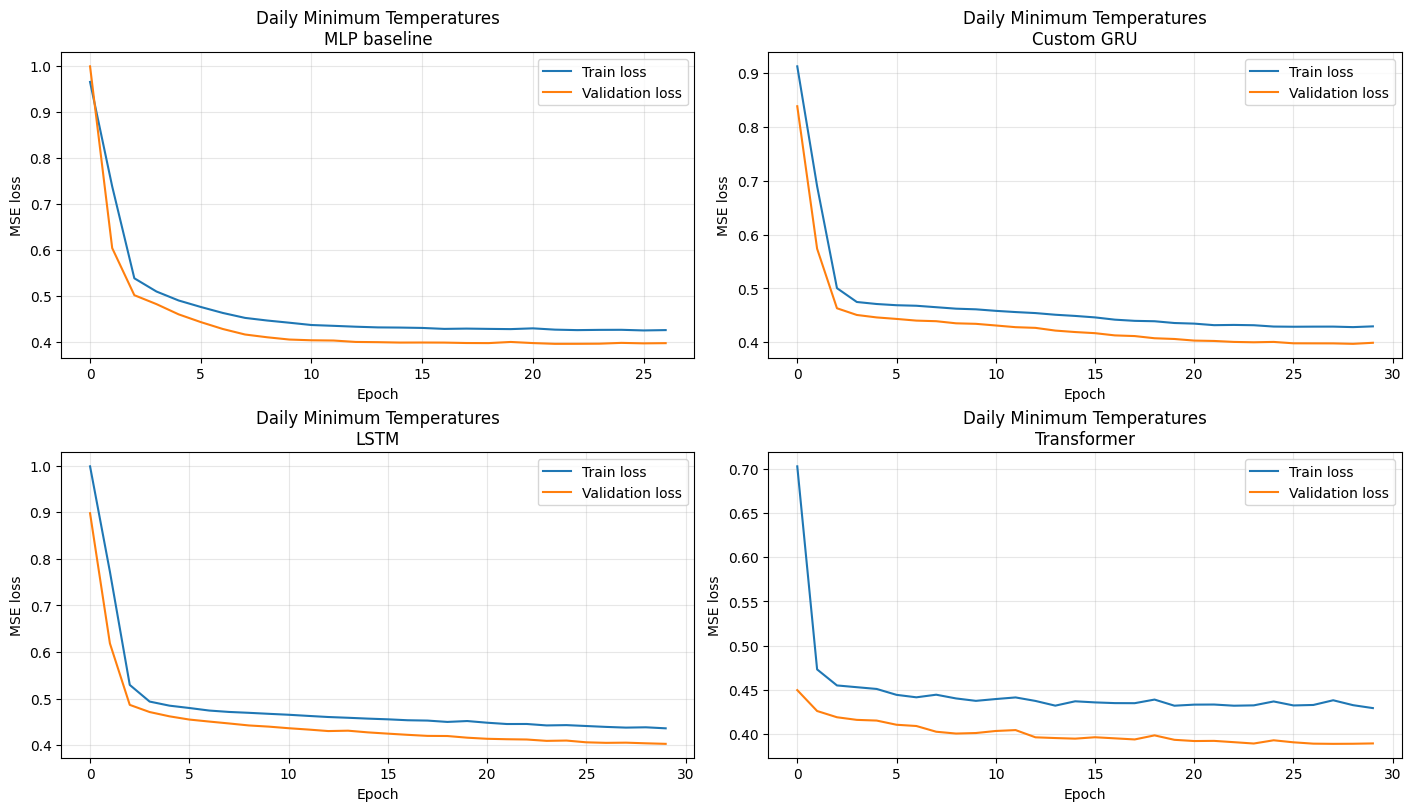

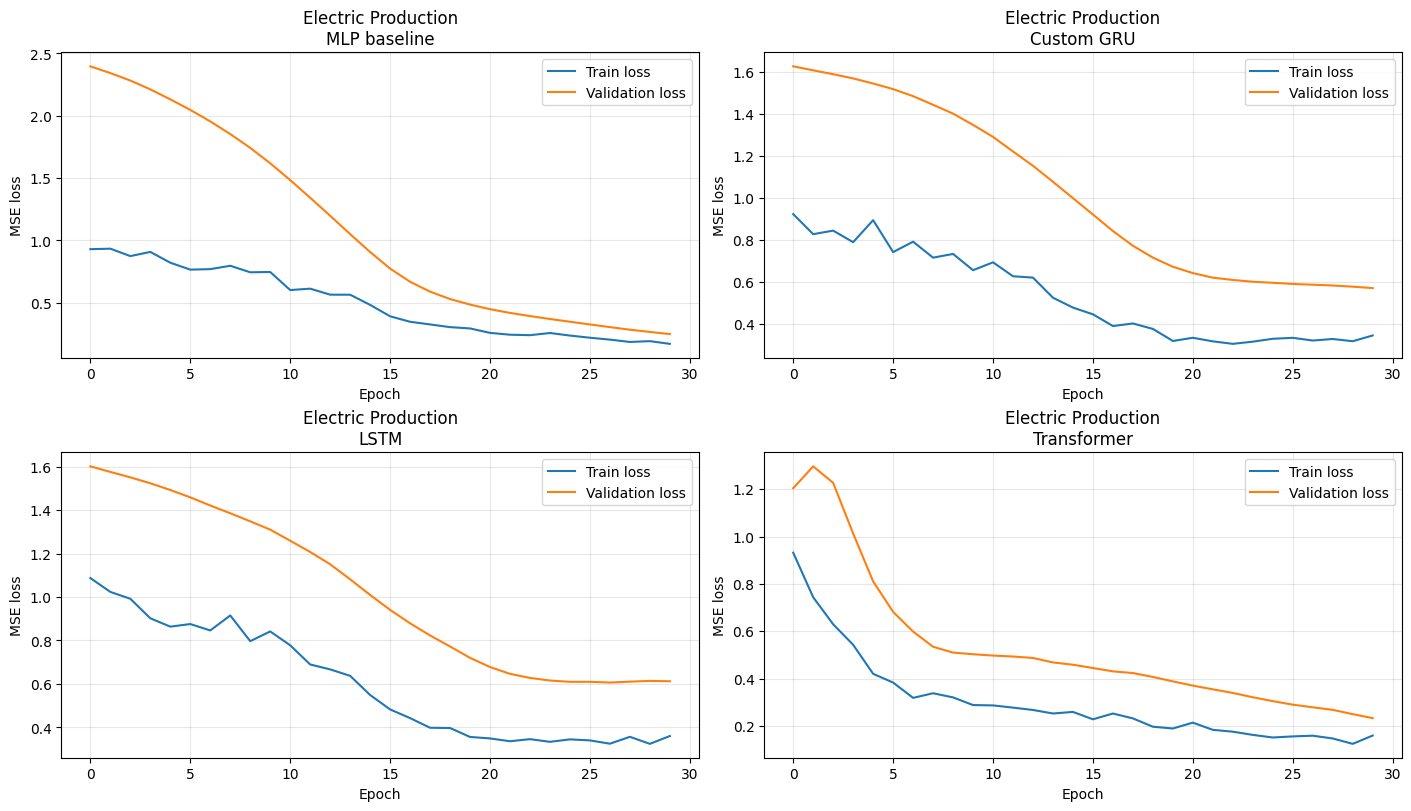

In [12]:
def plot_loss_curves(dataset_name, dataset_runs):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
    axes = axes.ravel()
    for ax, (model_name, run) in zip(axes, dataset_runs.items()):
        ax.plot(run["history"]["train_loss"], label="Train loss")
        ax.plot(run["history"]["val_loss"], label="Validation loss")
        ax.set_title(f"{dataset_name}\n{model_name}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("MSE loss")
        ax.grid(alpha=0.3)
        ax.legend()
    plt.show()


for dataset_name, dataset_runs in default_runs.items():
    plot_loss_curves(dataset_name, dataset_runs)

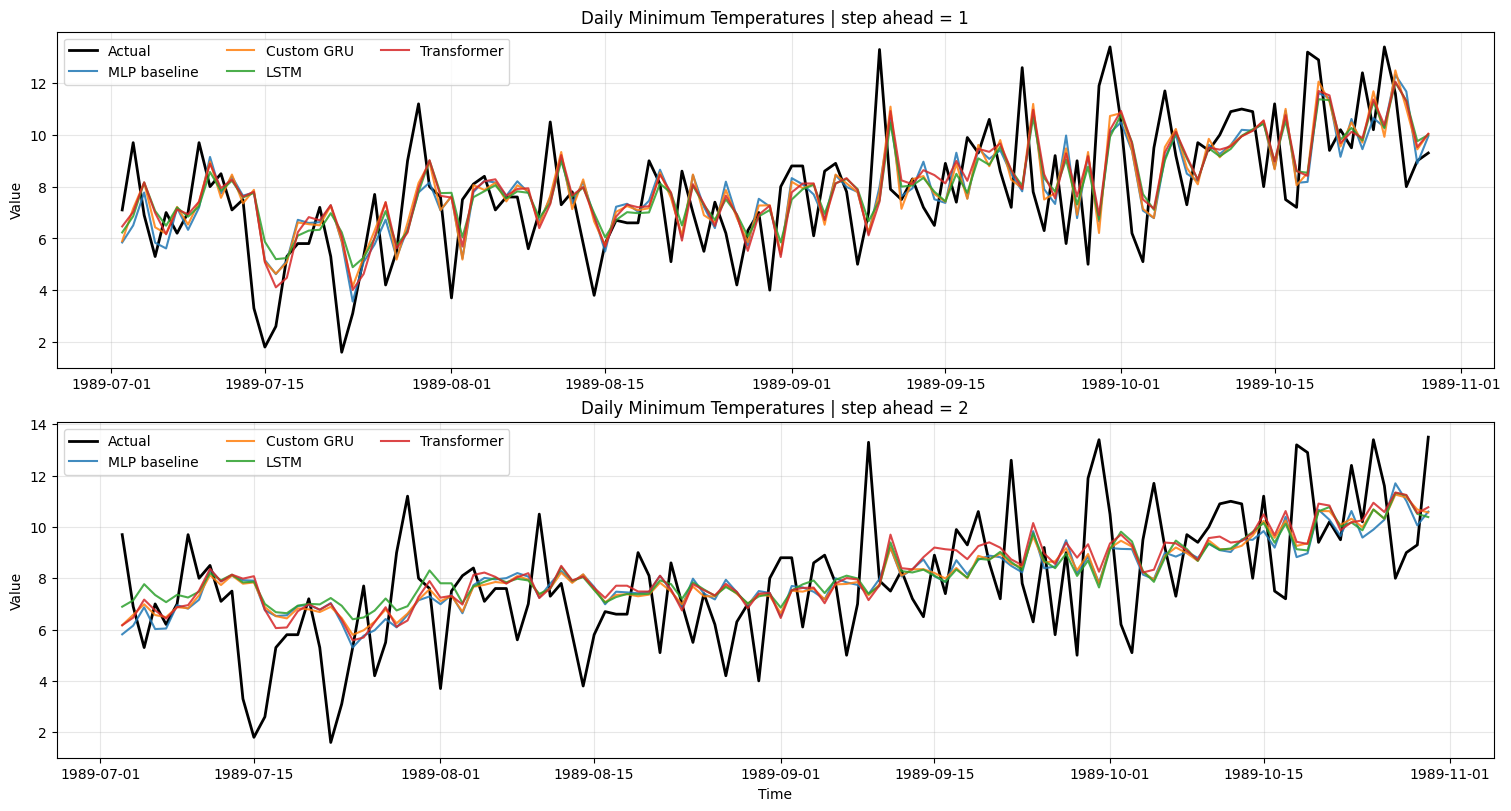

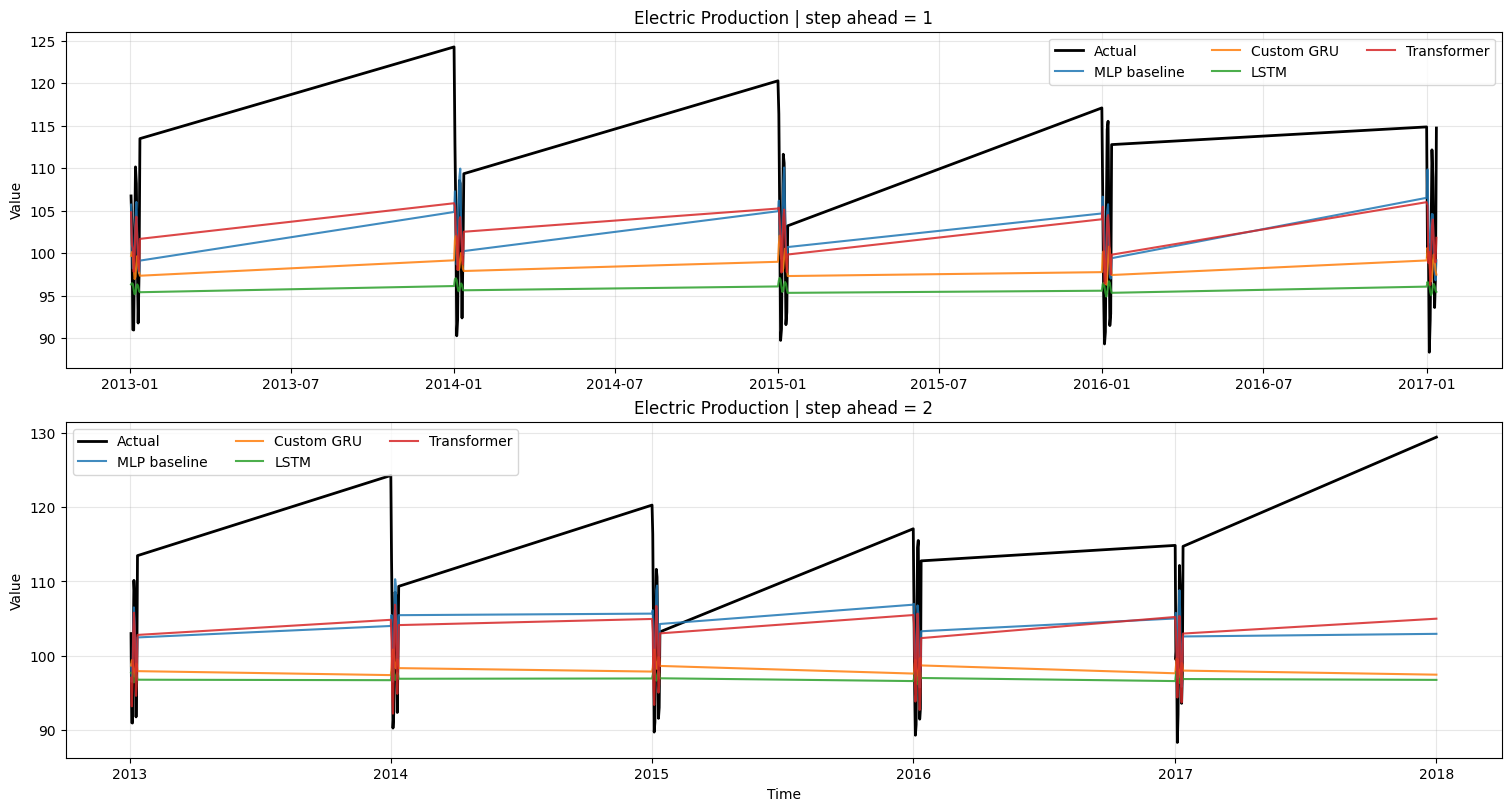

In [13]:
def plot_prediction_vs_actual(dataset_name, dataset_runs, max_points: int = 120):
    fig, axes = plt.subplots(2, 1, figsize=(15, 8), constrained_layout=True)

    for step_idx, ax in enumerate(axes, start=1):
        reference_run = next(iter(dataset_runs.values()))
        step_mask = reference_run["prediction_frame"]["step_ahead"] == step_idx
        reference_frame = reference_run["prediction_frame"].loc[step_mask].head(max_points)

        ax.plot(
            reference_frame["timestamp"],
            reference_frame["actual"],
            label="Actual",
            color="black",
            linewidth=2.0,
        )

        for model_name, run in dataset_runs.items():
            step_frame = run["prediction_frame"].loc[run["prediction_frame"]["step_ahead"] == step_idx].head(max_points)
            ax.plot(step_frame["timestamp"], step_frame["predicted"], label=model_name, alpha=0.85)

        ax.set_title(f"{dataset_name} | step ahead = {step_idx}")
        ax.set_ylabel("Value")
        ax.grid(alpha=0.3)
        ax.legend(ncol=3)

    axes[-1].set_xlabel("Time")
    plt.show()


for dataset_name, dataset_runs in default_runs.items():
    plot_prediction_vs_actual(dataset_name, dataset_runs)

Where the Custom GRU Fails:

Metrics are useful, but they do not show why errors happen. To make failures concrete, we inspect the single worst GRU test case on each dataset:

- the left part of the plot is the input window the GRU saw,
- the right part is the 2-step future it tried to predict,
- the mismatch reveals when the hidden-state summary is not enough.

Daily Minimum Temperatures


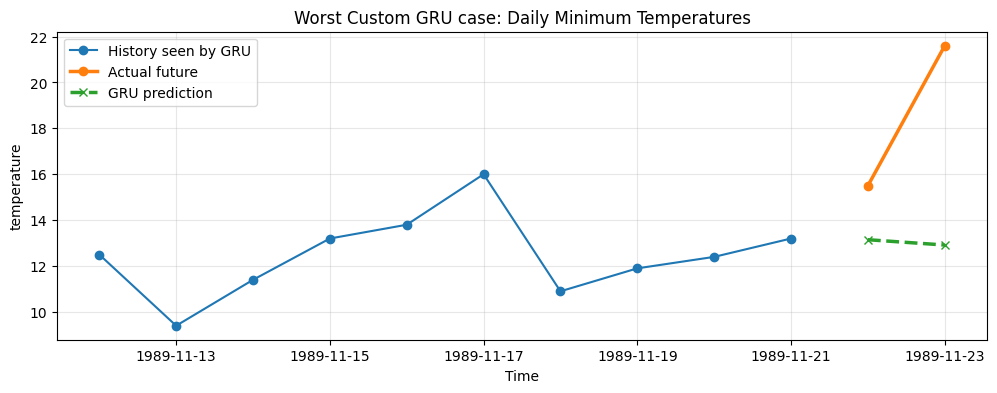

Last few observed rows before the failure:


,timestamp,temperature
5,1989-11-17,16.0
6,1989-11-18,10.9
7,1989-11-19,11.9
8,1989-11-20,12.4
9,1989-11-21,13.2


,timestamp,value,segment
5,1989-11-17,16.0,history
6,1989-11-18,10.9,history
7,1989-11-19,11.9,history
8,1989-11-20,12.4,history
9,1989-11-21,13.2,history
10,1989-11-22,15.5,actual future
11,1989-11-23,21.6,actual future


,timestamp,actual,predicted,abs_error
1,1989-11-23,21.6,12.9157,8.6843
0,1989-11-22,15.5,13.1474,2.3526


Electric Production


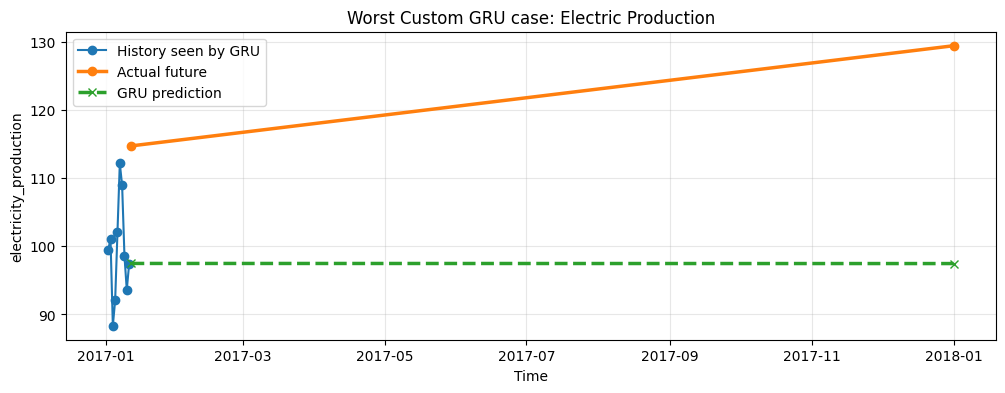

Last few observed rows before the failure:


,timestamp,electricity_production
5,2017-01-07,112.153801
6,2017-01-08,108.931198
7,2017-01-09,98.615402
8,2017-01-10,93.613701
9,2017-01-11,97.335899


,timestamp,value,segment
5,2017-01-07,112.153801,history
6,2017-01-08,108.931198,history
7,2017-01-09,98.615402,history
8,2017-01-10,93.613701,history
9,2017-01-11,97.335899,history
10,2017-01-12,114.721199,actual future
11,2018-01-01,129.404800,actual future


,timestamp,actual,predicted,abs_error
1,2018-01-01,129.404800,97.467400,31.937401
0,2017-01-12,114.721199,97.484596,17.236601


In [14]:
def show_worst_gru_case(problem, run):
    sample_idx = run["worst_sample_idx"]
    x_times = pd.to_datetime(problem["samples"]["test"]["x_times"][sample_idx])
    y_times = pd.to_datetime(problem["samples"]["test"]["y_times"][sample_idx])
    x_values = problem["samples"]["test"]["x_target_raw"][sample_idx]
    y_values = problem["samples"]["test"]["y_target_raw"][sample_idx]
    y_pred = run["pred_raw"][sample_idx]
    context_features = pd.DataFrame(
        problem["samples"]["test"]["x_feature_raw"][sample_idx],
        columns=problem["feature_columns"],
    )
    context_features.insert(0, "timestamp", x_times)

    summary = pd.DataFrame(
        {
            "timestamp": list(x_times) + list(y_times),
            "value": list(x_values) + list(y_values),
            "segment": ["history"] * len(x_values) + ["actual future"] * len(y_values),
        }
    )

    plt.figure(figsize=(12, 4))
    plt.plot(x_times, x_values, marker="o", label="History seen by GRU")
    plt.plot(y_times, y_values, marker="o", linewidth=2.5, label="Actual future")
    plt.plot(y_times, y_pred, marker="x", linestyle="--", linewidth=2.5, label="GRU prediction")
    plt.title(f"Worst Custom GRU case: {problem['name']}")
    plt.xlabel("Time")
    plt.ylabel(problem["target_column"])
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    detailed = pd.DataFrame(
        {
            "timestamp": y_times,
            "actual": y_values,
            "predicted": y_pred,
            "abs_error": np.abs(y_values - y_pred),
        }
    )
    return summary, detailed.sort_values("abs_error", ascending=False), context_features.tail(5)


for dataset_name, problem in problems.items():
    print(dataset_name)
    summary_table, error_table, context_tail = show_worst_gru_case(problem, default_runs[dataset_name]["Custom GRU"])
    print("Last few observed rows before the failure:")
    display(context_tail.round(4))
    display(summary_table.tail(problem["horizon"] + 5))
    display(error_table.round(4))

In [15]:
def show_top_gru_errors(dataset_name, run, top_k: int = 5):
    print(f"Top {top_k} absolute Custom GRU errors for {dataset_name}")
    display(
        run["prediction_frame"]
        .sort_values("abs_error", ascending=False)
        .head(top_k)
        .reset_index(drop=True)
        .round(4)
    )


for dataset_name, dataset_runs in default_runs.items():
    show_top_gru_errors(dataset_name, dataset_runs["Custom GRU"])

Top 5 absolute Custom GRU errors for Daily Minimum Temperatures


,sample_idx,step_ahead,timestamp,actual,predicted,abs_error
0,143,2,1989-11-23,21.6,12.9157,8.6843
1,449,2,1990-09-25,16.3,8.1974,8.1025
2,309,2,1990-05-08,4.9,12.6669,7.7669
3,444,2,1990-09-20,16.3,8.7860,7.5140
4,144,1,1989-11-23,21.6,14.4800,7.1200


Top 5 absolute Custom GRU errors for Electric Production


,sample_idx,step_ahead,timestamp,actual,predicted,abs_error
0,58,2,2018-01-01,129.4048,97.4674,31.9374
1,10,2,2014-01-01,124.2549,97.4089,26.8460
2,11,1,2014-01-01,124.2549,99.1616,25.0933
3,22,2,2015-01-01,120.2696,97.8835,22.3861
4,23,1,2015-01-01,120.2696,98.9899,21.2797


Failure Interpretation:

The custom GRU is expected to struggle most when the next two points break sharply away from the recent pattern inside the input window.

Typical reasons:

- the hidden state compresses history into a small vector of size 14,
- abrupt spikes are rare and hard to infer from smooth recent context,
- in the electricity production series, trend shifts and seasonal turning points can move faster than a short hidden summary can adapt.

In [22]:
def build_failure_summary(problem, run) -> str:
    worst_idx = run["worst_sample_idx"]
    future_actual = run["true_raw"][worst_idx]
    future_pred = run["pred_raw"][worst_idx]
    history = problem["samples"]["test"]["x_target_raw"][worst_idx]
    future_change = float(future_actual[-1] - history[-1])
    pred_change = float(future_pred[-1] - history[-1])

    return (
        f"- **{problem['name']}:** the worst GRU case happens when the future moves "
        f"{future_change:+.3f} away from the last observed value, but the model only moves "
        f"{pred_change:+.3f}. This is a concrete sign that the hidden state smooths over a turning point."
    )


failure_lines = []
for dataset_name, problem in problems.items():
    failure_lines.append(build_failure_summary(problem, default_runs[dataset_name]["Custom GRU"]))
display(Markdown("\n".join(failure_lines)))

- **Daily Minimum Temperatures:** the worst GRU case happens when the future moves +8.400 away from the last observed value, but the model only moves -0.284. This is a concrete sign that the hidden state smooths over a turning point.
- **Electric Production:** the worst GRU case happens when the future moves +32.069 away from the last observed value, but the model only moves +0.132. This is a concrete sign that the hidden state smooths over a turning point.

Ablation: How Much History Should the GRU See?

The assignment asks us to test the custom GRU with:

- half window size: 5
- original window size: 10
- double window size: 20

This ablation is useful because time-series forecasting is a trade-off:

- too short a window may miss seasonal structure,
- too long a window may inject stale or distracting information.

In [17]:
window_variants = {
    "half": max(1, window_size // 2),
    "original": window_size,
    "double": window_size * 2,
}

ablation_rows = []
ablation_runs = {}

for dataset_name, dataset_info in raw_series_catalog.items():
    ablation_runs[dataset_name] = {}
    for label, variant_window_size in window_variants.items():
        variant_problem = build_windowed_problem(dataset_info, variant_window_size, prediction_horizon)
        run = run_single_experiment(
            variant_problem,
            model_name=f"Custom GRU ({label})",
            model_builder=lambda problem: CustomGRU(problem["num_features"], hidden_size, prediction_horizon),
        )
        ablation_runs[dataset_name][label] = {"problem": variant_problem, "run": run}
        ablation_rows.append(
            {
                "dataset": dataset_name,
                "window_variant": label,
                "window_size": variant_window_size,
                **run["metrics"],
            }
        )

ablation_df = pd.DataFrame(ablation_rows).sort_values(["dataset", "window_size"]).reset_index(drop=True)
ablation_df.round(4)

,dataset,window_variant,window_size,MSE,MAE,RMSE
0,Daily Minimum Temperatures,half,5,5.9966,1.9091,2.4488
1,Daily Minimum Temperatures,original,10,5.7237,1.8574,2.3924
2,Daily Minimum Temperatures,double,20,5.6954,1.8442,2.3865
3,Electric Production,half,5,120.1408,9.0495,10.9609
4,Electric Production,original,10,116.8646,8.8691,10.8104
5,Electric Production,double,20,113.5577,8.7473,10.6563


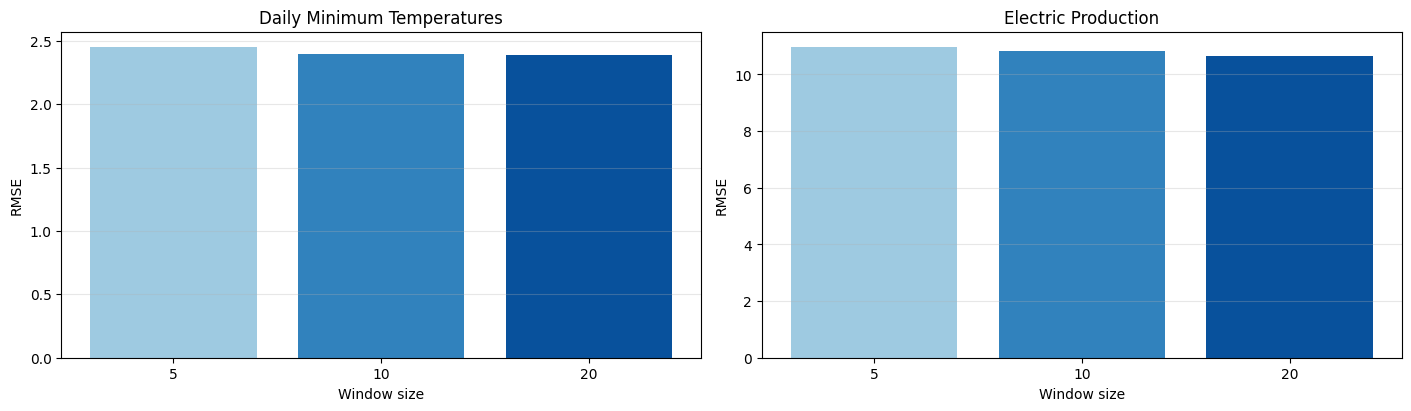

In [18]:
def plot_ablation(ablation_table: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

    for ax, dataset_name in zip(axes, ablation_table["dataset"].unique()):
        subset = ablation_table[ablation_table["dataset"] == dataset_name].sort_values("window_size")
        ax.bar(subset["window_size"].astype(str), subset["RMSE"], color=["#9ecae1", "#3182bd", "#08519c"])
        ax.set_title(dataset_name)
        ax.set_xlabel("Window size")
        ax.set_ylabel("RMSE")
        ax.grid(axis="y", alpha=0.3)

    plt.show()


plot_ablation(ablation_df)

In [19]:
for dataset_name in ablation_df["dataset"].unique():
    subset = ablation_df[ablation_df["dataset"] == dataset_name].sort_values("RMSE")
    best_row = subset.iloc[0]
    worst_row = subset.iloc[-1]
    print(dataset_name)
    print(
        f"  Best GRU window: {int(best_row['window_size'])} "
        f"(RMSE={best_row['RMSE']:.4f})"
    )
    print(
        f"  Weakest GRU window: {int(worst_row['window_size'])} "
        f"(RMSE={worst_row['RMSE']:.4f})"
    )
    print()

Daily Minimum Temperatures
  Best GRU window: 20 (RMSE=2.3865)
  Weakest GRU window: 5 (RMSE=2.4488)

Electric Production
  Best GRU window: 20 (RMSE=10.6563)
  Weakest GRU window: 5 (RMSE=10.9609)



In [23]:
def build_ablation_summary(ablation_table: pd.DataFrame) -> str:
    lines = []
    for dataset_name in ablation_table["dataset"].unique():
        subset = ablation_table[ablation_table["dataset"] == dataset_name].sort_values("window_size")
        best_row = subset.sort_values("RMSE").iloc[0]
        baseline_row = subset[subset["window_size"] == window_size].iloc[0]
        lines.append(
            f"- **{dataset_name}:** the best GRU window is **{int(best_row['window_size'])}** "
            f"(RMSE {best_row['RMSE']:.4f}). The original assignment window `{window_size}` scored "
            f"{baseline_row['RMSE']:.4f}."
        )
    return "\n".join(lines)


display(Markdown(build_ablation_summary(ablation_df)))

- **Daily Minimum Temperatures:** the best GRU window is **20** (RMSE 2.3865). The original assignment window `10` scored 2.3924.
- **Electric Production:** the best GRU window is **20** (RMSE 10.6563). The original assignment window `10` scored 10.8104.